# ICICoS 2026 — Final All-in-One Reviewer-Compliant Reevaluation

Notebook ini dibuat untuk menyatukan seluruh kebutuhan reviewer dalam **satu pipeline final**.

## Tujuan utama

1. Menggunakan threshold final yang dipilih dari **validation set** dengan grid 0.01:
   - AE--MLP = 0.72
   - MLP = 0.89
   - LightGBM = 0.68

2. Mengulang evaluasi final secara konsisten:
   - CSE-CIC-IDS2018 test set
   - CICIDS2017 cross-dataset
   - unseen subset: PortScan, Infiltration, Heartbleed
   - per-class detection
   - confidence interval untuk kelas kecil

3. Menghasilkan benchmark komputasi yang adil:
   - setiap model dijalankan dalam **subprocess terpisah**
   - model dimuat dari awal untuk setiap benchmark model
   - CPU/memory dihitung dari proses bersih per model
   - tidak perlu manual enable/disable model

4. Menghasilkan output paper-ready:
   - Table I
   - Table II
   - Table III
   - Table IV
   - Table V
   - confusion matrix figure
   - reconstruction-error ECDF
   - sequential benchmark figure
   - CI summary
   - reviewer checklist summary

## Catatan akademik penting

Notebook ini tidak melakukan retraining. Semua model dianggap sudah final/frozen. Threshold dipilih dari validation set dan digunakan secara frozen untuk test dan cross-dataset evaluation.


In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import gc
import re
import json
import math
import time
import zipfile
import shutil
import joblib
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    auc,
)

np.random.seed(42)

print("Python:", sys.version)
print("Working directory:", os.getcwd())


Mounted at /content/drive
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Working directory: /content


In [2]:
# ============================================================
# CELL 2 — FINAL CONFIG
# ============================================================

BASE_CICIDS = Path("/content/drive/MyDrive/CICIDS2018")
BASE_COLAB = Path("/content/drive/MyDrive/Colab Notebooks")

OUT_DIR = BASE_CICIDS / "ICICoS2026_FINAL_all_in_one_reviewer_compliant"
PREP_DIR = OUT_DIR / "prepared_arrays"
PRED_DIR = OUT_DIR / "predictions"
BENCH_DIR = OUT_DIR / "benchmark"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "paper_ready_tables"
LOG_DIR = OUT_DIR / "logs"

for d in [OUT_DIR, PREP_DIR, PRED_DIR, BENCH_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Final reviewer-safe thresholds:
# selected from validation set using grid 0.01
THRESHOLDS = {
    "AE-MLP": 0.72,
    "MLP": 0.89,
    "LightGBM": 0.68,
}

MODEL_ORDER = ["AE-MLP", "MLP", "LightGBM"]

SEQUENTIAL_VOLUMES = [1, 10, 100, 1000, 5000, 10000]
BATCH_SIZE = 4096
RESOURCE_SAMPLE_INTERVAL_S = 0.05
BOOTSTRAP_B = 2000
RANDOM_STATE = 42

ZERO_DAY_LABEL = "Infiltration"
UNSEEN_ATTACKS = ["PortScan", "Infiltration", "Heartbleed"]

# Final dataset and model paths based on your current Drive folder.
DATASET_CANDIDATES = [
    BASE_CICIDS / "dataset_splitt.joblib",
    BASE_CICIDS / "dataset_split.joblib",
]

SCALER_CANDIDATES = [
    BASE_CICIDS / "scaler.pkl",
]

MODEL_CANDIDATES = {
    "AE-MLP": {
        "ae": [
            BASE_CICIDS / "ae_model_final.keras",
            BASE_CICIDS / "ae_model_final.h5",
        ],
        "encoder": [
            BASE_CICIDS / "ae_encoder_final.keras",
            BASE_CICIDS / "ae_encoder_final.h5",
        ],
        "classifier": [
            BASE_CICIDS / "ae_mlp_final.keras",
            BASE_CICIDS / "ae_mlp_final.h5",
        ],
    },
    "MLP": {
        "model": [
            BASE_CICIDS / "mlp_model_final.keras",
            BASE_CICIDS / "mlp_model_final.h5",
        ],
    },
    "LightGBM": {
        "model": [
            BASE_CICIDS / "lgbm_model_final.txt",
            BASE_CICIDS / "lgbm_model_final.joblib",
        ],
    },
}

# CICIDS2017 source.
# This version follows the old cross-dataset notebook idea:
# - use MachineLearningCSV.zip if the CSV folder is not extracted yet
# - extract automatically
# - apply explicit CICIDS2017-to-CSE-CIC-IDS2018 column-name mapping
# - stop if any required feature is missing, so no zero-fill is used
CICIDS2017_ZIP_CANDIDATES = [
    BASE_CICIDS / "MachineLearningCSV.zip",
]

CICIDS2017_EXTRACT_DIR = BASE_CICIDS / "MachineLearningCSV_extracted"

CICIDS2017_DIR_CANDIDATES = [
    CICIDS2017_EXTRACT_DIR,
    CICIDS2017_EXTRACT_DIR / "MachineLearningCSV",
    CICIDS2017_EXTRACT_DIR / "MachineLearningCSV" / "MachineLearningCVE",
    BASE_CICIDS / "MachineLearningCSV",
    BASE_CICIDS / "MachineLearningCSV" / "MachineLearningCVE",
]

print("OUT_DIR:", OUT_DIR)
print("THRESHOLDS:", THRESHOLDS)

print("\nCICIDS2017 zip candidates:")
for p in CICIDS2017_ZIP_CANDIDATES:
    print(" -", p, "FOUND" if p.exists() else "MISSING")

print("\nCICIDS2017 folder candidates:")
for p in CICIDS2017_DIR_CANDIDATES:
    print(" -", p, "FOUND" if p.exists() else "MISSING")


OUT_DIR: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant
THRESHOLDS: {'AE-MLP': 0.72, 'MLP': 0.89, 'LightGBM': 0.68}

CICIDS2017 zip candidates:
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV.zip FOUND

CICIDS2017 folder candidates:
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV_extracted MISSING
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV_extracted/MachineLearningCSV MISSING
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV_extracted/MachineLearningCSV/MachineLearningCVE MISSING
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV MISSING
 - /content/drive/MyDrive/CICIDS2018/MachineLearningCSV/MachineLearningCVE MISSING


In [3]:
# ============================================================
# CELL 3 — DISCOVER ARTIFACTS
# ============================================================

def first_existing(paths, required=True, name="artifact"):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    if required:
        msg = f"Tidak menemukan {name}. Candidate paths:\\n" + "\\n".join([str(p) for p in paths])
        raise FileNotFoundError(msg)
    return None

def path_size_mb(path):
    path = Path(path)
    if not path.exists():
        return float("nan")
    if path.is_file():
        return path.stat().st_size / (1024 ** 2)
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / (1024 ** 2)

DATASET_PATH = first_existing(DATASET_CANDIDATES, name="dataset_split.joblib")

MODEL_PATHS = {}
MODEL_PATHS["AE-MLP"] = {
    "ae": first_existing(MODEL_CANDIDATES["AE-MLP"]["ae"], name="AE model"),
    "encoder": first_existing(MODEL_CANDIDATES["AE-MLP"]["encoder"], name="AE encoder"),
    "classifier": first_existing(MODEL_CANDIDATES["AE-MLP"]["classifier"], name="AE-MLP classifier"),
}
MODEL_PATHS["MLP"] = {
    "model": first_existing(MODEL_CANDIDATES["MLP"]["model"], name="MLP model"),
}
MODEL_PATHS["LightGBM"] = {
    "model": first_existing(MODEL_CANDIDATES["LightGBM"]["model"], name="LightGBM model"),
}

print("Dataset:", DATASET_PATH)
print("\\nModel paths:")
for m, paths in MODEL_PATHS.items():
    print(m)
    for k, p in paths.items():
        print("  ", k, ":", p, f"({path_size_mb(p):.3f} MB)")

artifact_discovery = {
    "dataset_path": str(DATASET_PATH),
    "thresholds": THRESHOLDS,
    "model_paths": {m: {k: str(v) for k, v in paths.items()} for m, paths in MODEL_PATHS.items()},
}

with open(OUT_DIR / "artifact_discovery.json", "w", encoding="utf-8") as f:
    json.dump(artifact_discovery, f, indent=2)


Dataset: /content/drive/MyDrive/CICIDS2018/dataset_splitt.joblib
\nModel paths:
AE-MLP
   ae : /content/drive/MyDrive/CICIDS2018/ae_model_final.keras (0.050 MB)
   encoder : /content/drive/MyDrive/CICIDS2018/ae_encoder_final.keras (0.032 MB)
   classifier : /content/drive/MyDrive/CICIDS2018/ae_mlp_final.keras (0.064 MB)
MLP
   model : /content/drive/MyDrive/CICIDS2018/mlp_model_final.keras (0.797 MB)
LightGBM
   model : /content/drive/MyDrive/CICIDS2018/lgbm_model_final.txt (6.933 MB)


In [4]:
# ============================================================
# CELL 4 — LOAD PRIMARY DATASET AND PREPARE SHARED ARRAYS
# ============================================================

print("Loading primary dataset:", DATASET_PATH)
data = joblib.load(DATASET_PATH)

X_test = np.asarray(data["X_test"], dtype="float32")
y_test = np.asarray(data["y_test"], dtype=int)
labels_test = np.asarray(data["label_test"]).astype(str)

features = data.get("features", None)
if features is None:
    features = data.get("feature_names", None)
if features is None:
    raise KeyError("Tidak menemukan key features / feature_names di dataset joblib.")

features = [str(f) for f in features]
n_features = len(features)

# Find transformer/scaler. Preferred from joblib if present; otherwise external file.
scaler = None
scaler_source = None
for key in ["scaler", "transformer", "quantile_transformer", "qt"]:
    if key in data:
        scaler = data[key]
        scaler_source = f"dataset_joblib:{key}"
        break

if scaler is None:
    scaler_path = first_existing(SCALER_CANDIDATES, required=False, name="scaler.pkl")
    if scaler_path is not None:
        scaler = joblib.load(scaler_path)
        scaler_source = str(scaler_path)

if scaler is None:
    raise FileNotFoundError(
        "Scaler/QuantileTransformer tidak ditemukan. Pastikan dataset joblib berisi scaler "
        "atau ada scaler.pkl di folder kandidat."
    )

np.save(PREP_DIR / "cse_X_test.npy", X_test)
np.save(PREP_DIR / "cse_y_test.npy", y_test)
pd.Series(labels_test, name="label").to_csv(PREP_DIR / "cse_labels_test.csv", index=False)
pd.Series(features, name="feature").to_csv(PREP_DIR / "feature_order_38.csv", index=False)
joblib.dump(scaler, PREP_DIR / "training_fitted_transformer.joblib")

dataset_summary = {
    "X_test_shape": list(X_test.shape),
    "y_test_shape": list(y_test.shape),
    "labels_test_shape": list(labels_test.shape),
    "n_features": n_features,
    "features": features,
    "scaler_source": scaler_source,
    "test_label_distribution": pd.Series(labels_test).value_counts().to_dict(),
}

with open(OUT_DIR / "primary_dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, indent=2)

print("X_test:", X_test.shape)
print("n_features:", n_features)
print("Scaler source:", scaler_source)
print("\\nTest label distribution:")
print(pd.Series(labels_test).value_counts().to_string())


Loading primary dataset: /content/drive/MyDrive/CICIDS2018/dataset_splitt.joblib
X_test: (1759848, 38)
n_features: 38
Scaler source: /content/drive/MyDrive/CICIDS2018/scaler.pkl
\nTest label distribution:
Benign                      1347722
DDOS attack-HOIC             102902
DDoS attacks-LOIC-HTTP        86428
DoS attacks-Hulk              69287
Bot                           42928
FTP-BruteForce                29004
SSH-Bruteforce                28139
Infiltration                  24180
DoS attacks-SlowHTTPTest      20983
DoS attacks-GoldenEye          6227
DoS attacks-Slowloris          1648
DDOS attack-LOIC-UDP            260
Brute Force -Web                 92
Brute Force -XSS                 35
SQL Injection                    13


In [5]:
# ============================================================
# CELL 5 — PREPARE CICIDS2017 CROSS-DATASET
# Old-notebook-compatible mapping + ZIP extraction + no zero-fill.
#
# This cell intentionally follows the old cross-dataset logic:
# 1. Extract MachineLearningCSV.zip if needed.
# 2. Clean CICIDS2017 column names.
# 3. Map CICIDS2017 names to CSE-CIC-IDS2018 feature names.
# 4. Verify all 38 required features exist.
# 5. Drop only non-finite rows.
# 6. Apply the training-fitted transformer without refitting.
# ============================================================

import zipfile
import re
from collections import Counter

COL_MAP_17_TO_18 = {
    "Destination Port": "Dst Port",
    "Flow Duration": "Flow Duration",

    "Total Fwd Packets": "Tot Fwd Pkts",
    "Total Backward Packets": "Tot Bwd Pkts",
    "Total Length of Fwd Packets": "TotLen Fwd Pkts",
    "Total Length of Bwd Packets": "TotLen Bwd Pkts",

    "Fwd Packet Length Max": "Fwd Pkt Len Max",
    "Fwd Packet Length Min": "Fwd Pkt Len Min",
    "Fwd Packet Length Mean": "Fwd Pkt Len Mean",
    "Fwd Packet Length Std": "Fwd Pkt Len Std",

    "Bwd Packet Length Max": "Bwd Pkt Len Max",
    "Bwd Packet Length Min": "Bwd Pkt Len Min",
    "Bwd Packet Length Mean": "Bwd Pkt Len Mean",
    "Bwd Packet Length Std": "Bwd Pkt Len Std",

    "Flow Bytes/s": "Flow Byts/s",
    "Flow Packets/s": "Flow Pkts/s",

    "Flow IAT Mean": "Flow IAT Mean",
    "Flow IAT Std": "Flow IAT Std",
    "Flow IAT Max": "Flow IAT Max",
    "Flow IAT Min": "Flow IAT Min",

    "Fwd IAT Total": "Fwd IAT Tot",
    "Fwd IAT Mean": "Fwd IAT Mean",
    "Fwd IAT Std": "Fwd IAT Std",
    "Fwd IAT Max": "Fwd IAT Max",
    "Fwd IAT Min": "Fwd IAT Min",

    "Bwd IAT Total": "Bwd IAT Tot",
    "Bwd IAT Mean": "Bwd IAT Mean",
    "Bwd IAT Std": "Bwd IAT Std",
    "Bwd IAT Max": "Bwd IAT Max",
    "Bwd IAT Min": "Bwd IAT Min",

    "Fwd PSH Flags": "Fwd PSH Flags",
    "Bwd PSH Flags": "Bwd PSH Flags",
    "Fwd URG Flags": "Fwd URG Flags",
    "Bwd URG Flags": "Bwd URG Flags",

    "Fwd Header Length": "Fwd Header Len",
    "Bwd Header Length": "Bwd Header Len",

    "Fwd Packets/s": "Fwd Pkts/s",
    "Bwd Packets/s": "Bwd Pkts/s",

    "Min Packet Length": "Pkt Len Min",
    "Max Packet Length": "Pkt Len Max",
    "Packet Length Mean": "Pkt Len Mean",
    "Packet Length Std": "Pkt Len Std",
    "Packet Length Variance": "Pkt Len Var",

    "FIN Flag Count": "FIN Flag Cnt",
    "SYN Flag Count": "SYN Flag Cnt",
    "RST Flag Count": "RST Flag Cnt",
    "PSH Flag Count": "PSH Flag Cnt",
    "ACK Flag Count": "ACK Flag Cnt",
    "URG Flag Count": "URG Flag Cnt",
    "CWE Flag Count": "CWE Flag Count",
    "ECE Flag Count": "ECE Flag Cnt",

    "Down/Up Ratio": "Down/Up Ratio",
    "Average Packet Size": "Pkt Size Avg",
    "Avg Fwd Segment Size": "Fwd Seg Size Avg",
    "Avg Bwd Segment Size": "Bwd Seg Size Avg",

    "Fwd Avg Bytes/Bulk": "Fwd Byts/b Avg",
    "Fwd Avg Packets/Bulk": "Fwd Pkts/b Avg",
    "Fwd Avg Bulk Rate": "Fwd Blk Rate Avg",
    "Bwd Avg Bytes/Bulk": "Bwd Byts/b Avg",
    "Bwd Avg Packets/Bulk": "Bwd Pkts/b Avg",
    "Bwd Avg Bulk Rate": "Bwd Blk Rate Avg",

    "Subflow Fwd Packets": "Subflow Fwd Pkts",
    "Subflow Fwd Bytes": "Subflow Fwd Byts",
    "Subflow Bwd Packets": "Subflow Bwd Pkts",
    "Subflow Bwd Bytes": "Subflow Bwd Byts",

    "Init_Win_bytes_forward": "Init Fwd Win Byts",
    "Init_Win_bytes_backward": "Init Bwd Win Byts",
    "act_data_pkt_fwd": "Fwd Act Data Pkts",
    "min_seg_size_forward": "Fwd Seg Size Min",

    "Active Mean": "Active Mean",
    "Active Std": "Active Std",
    "Active Max": "Active Max",
    "Active Min": "Active Min",

    "Idle Mean": "Idle Mean",
    "Idle Std": "Idle Std",
    "Idle Max": "Idle Max",
    "Idle Min": "Idle Min",
}

def clean_col(c):
    return str(c).replace("\ufeff", "").strip()

def map_columns(columns):
    cleaned = [clean_col(c) for c in columns]
    mapped = [COL_MAP_17_TO_18.get(c, c) for c in cleaned]
    return mapped

def normalize_label(x):
    s = str(x).strip()
    s = s.replace("\ufeff", "")
    s = s.replace("�", "-")
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s)

    lower = s.lower()

    if lower == "benign":
        return "BENIGN"

    if "brute force" in lower and "web" in lower:
        return "Web Attack - Brute Force"

    if "xss" in lower and "web" in lower:
        return "Web Attack - XSS"

    if "sql" in lower and "injection" in lower:
        return "Web Attack - SQL Injection"

    if "infiltration" in lower or "infilteration" in lower:
        return "Infiltration"

    return s

def find_cicids2017_csv_files():
    # 1) Try existing extracted folders first
    for d in CICIDS2017_DIR_CANDIDATES:
        d = Path(d)
        if d.exists():
            files = sorted(d.rglob("*.csv"))
            if len(files) > 0:
                print("Using existing CICIDS2017 CSV folder:", d)
                return d, files

    # 2) If no CSV folder exists, extract MachineLearningCSV.zip
    zip_path = None
    for z in CICIDS2017_ZIP_CANDIDATES:
        z = Path(z)
        if z.exists():
            zip_path = z
            break

    if zip_path is None:
        raise FileNotFoundError(
            "CICIDS2017 CSV folder and MachineLearningCSV.zip were not found."
        )

    print("Extracting CICIDS2017 ZIP:")
    print(" - ZIP       :", zip_path)
    print(" - Extract to:", CICIDS2017_EXTRACT_DIR)

    CICIDS2017_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(CICIDS2017_EXTRACT_DIR)

    # 3) Search preferred folders after extraction
    for d in CICIDS2017_DIR_CANDIDATES:
        d = Path(d)
        if d.exists():
            files = sorted(d.rglob("*.csv"))
            if len(files) > 0:
                print("Using extracted CICIDS2017 CSV folder:", d)
                print("CSV files found:", len(files))
                return d, files

    # 4) Fallback search entire extracted directory
    files = sorted(CICIDS2017_EXTRACT_DIR.rglob("*.csv"))
    if len(files) > 0:
        print("Using extracted CICIDS2017 fallback folder:", CICIDS2017_EXTRACT_DIR)
        print("CSV files found:", len(files))
        return CICIDS2017_EXTRACT_DIR, files

    raise FileNotFoundError(
        "MachineLearningCSV.zip was extracted, but no CSV files were found."
    )

CROSS_CACHE = PREP_DIR / "cicids2017_crossdataset_prepared_scaled.npz"

# If you changed feature mapping or source ZIP and want a clean rerun, set this to True.
FORCE_REBUILD_CROSSDATASET = False

if CROSS_CACHE.exists() and not FORCE_REBUILD_CROSSDATASET:
    print("Using cached cross-dataset prepared file:", CROSS_CACHE)
    arr = np.load(CROSS_CACHE, allow_pickle=True)
    X_cross = arr["X_cross"].astype("float32")
    y_cross = arr["y_cross"].astype(int)
    labels_cross = arr["labels_cross"].astype(str)
    feature_coverage_df = pd.read_csv(PREP_DIR / "cicids2017_feature_coverage_audit.csv")
else:
    csv_dir, csv_files = find_cicids2017_csv_files()

    print("\nCICIDS2017 CSV files found:", len(csv_files))
    for p in csv_files:
        print(" -", p.name)

    all_parts = []
    audit_rows = []
    file_label_rows = []
    invalid_label_counter = Counter()
    valid_label_counter = Counter()

    total_raw_rows = 0
    total_nonfinite_dropped = 0

    for csv_path in csv_files:
        fname = csv_path.name
        print("\nProcessing:", fname)

        # Header audit only
        head = pd.read_csv(csv_path, nrows=5, encoding="latin1", low_memory=False)
        mapped_cols = map_columns(head.columns)

        file_missing = [f for f in features if f not in mapped_cols]
        file_present = [f for f in features if f in mapped_cols]

        audit_rows.append({
            "Source_File": fname,
            "Rows_Raw_Header_Audit": "see_processing_log",
            "Required_Features": len(features),
            "Found_Features": len(file_present),
            "Missing_Features_Count": len(file_missing),
            "Coverage (%)": len(file_present) / len(features) * 100,
            "Missing_Feature_List": "; ".join(file_missing),
            "Zero_Filled_Placeholders_Used": False,
        })

        if file_missing:
            raise ValueError(
                f"STOP: Missing required features in {fname}: {file_missing}. "
                "Notebook dihentikan agar tidak menggunakan zero-fill."
            )

        del head

        chunk_id = 0
        for chunk in pd.read_csv(
            csv_path,
            chunksize=100000,
            encoding="latin1",
            low_memory=False
        ):
            chunk_id += 1
            total_raw_rows += len(chunk)

            chunk.columns = map_columns(chunk.columns)

            if "Label" not in chunk.columns:
                raise ValueError(f"Kolom Label tidak ditemukan di {fname}")

            missing = [f for f in features if f not in chunk.columns]
            if missing:
                raise ValueError(
                    f"STOP: Missing feature pada chunk {chunk_id}, file {fname}: {missing}. "
                    "Tidak dilakukan zero-fill."
                )

            labels_part = chunk["Label"].map(normalize_label).astype(str).values
            y_part = (labels_part != "BENIGN").astype(int)

            X_df = chunk[features].copy()
            for col in features:
                X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

            X_np = X_df.values.astype("float64")
            finite_mask = np.isfinite(X_np).all(axis=1)

            invalid_labels = labels_part[~finite_mask]
            valid_labels = labels_part[finite_mask]
            valid_y = y_part[finite_mask]
            X_valid_raw = X_np[finite_mask].astype("float32")

            total_nonfinite_dropped += int((~finite_mask).sum())
            invalid_label_counter.update(invalid_labels.tolist())
            valid_label_counter.update(valid_labels.tolist())

            if len(valid_y) == 0:
                del chunk, X_df, X_np
                continue

            # Apply the single training-fitted transformer used by the final pipeline.
            X_scaled = scaler.transform(X_valid_raw).astype("float32")

            part_df = pd.DataFrame(X_scaled, columns=features)
            part_df["__label__"] = valid_labels
            part_df["__y__"] = valid_y
            all_parts.append(part_df)

            if chunk_id % 5 == 0:
                print(
                    f"  chunk {chunk_id} | total valid so far: "
                    f"{sum(len(x) for x in all_parts):,} | dropped non-finite: {total_nonfinite_dropped:,}"
                )

            del chunk, X_df, X_np, X_valid_raw, X_scaled, part_df
            gc.collect()

    cross_df = pd.concat(all_parts, axis=0, ignore_index=True)

    X_cross = cross_df[features].to_numpy(dtype="float32")
    labels_cross = cross_df["__label__"].astype(str).values
    y_cross = cross_df["__y__"].to_numpy(dtype=int)

    feature_coverage_df = pd.DataFrame(audit_rows)
    feature_coverage_df.to_csv(PREP_DIR / "cicids2017_feature_coverage_audit.csv", index=False)

    df_valid_labels = pd.DataFrame(
        [{"Label": k, "Evaluated_Count": v} for k, v in valid_label_counter.items()]
    ).sort_values("Evaluated_Count", ascending=False)
    df_invalid_labels = pd.DataFrame(
        [{"Label": k, "Invalid_Count": v} for k, v in invalid_label_counter.items()]
    ).sort_values("Invalid_Count", ascending=False)

    df_valid_labels.to_csv(PREP_DIR / "cicids2017_evaluated_label_distribution.csv", index=False)
    df_invalid_labels.to_csv(PREP_DIR / "cicids2017_invalid_rows_dropped_by_label.csv", index=False)

    np.savez_compressed(
        CROSS_CACHE,
        X_cross=X_cross,
        y_cross=y_cross,
        labels_cross=labels_cross,
        features=np.array(features, dtype=object),
        total_raw_rows=total_raw_rows,
        total_nonfinite_dropped=total_nonfinite_dropped,
        zero_filled_placeholders_used=False,
    )

    print("\nSaved cross-dataset cache:", CROSS_CACHE)

print("\nCross dataset shape:", X_cross.shape)
print("Cross labels:", len(labels_cross))
print("Cross y distribution:", np.bincount(y_cross))

print("\nFeature coverage audit:")
display(feature_coverage_df)

print("\nCross-dataset label distribution:")
print(pd.Series(labels_cross).value_counts().to_string())

cross_summary = {
    "cross_shape": list(X_cross.shape),
    "cross_y_distribution": pd.Series(y_cross).value_counts().to_dict(),
    "cross_label_distribution": pd.Series(labels_cross).value_counts().to_dict(),
    "zero_filled_placeholders_used": False,
    "feature_coverage_all_38": bool((feature_coverage_df["Missing_Features_Count"] == 0).all()),
    "raw_rows": int(np.load(CROSS_CACHE, allow_pickle=True)["total_raw_rows"]) if CROSS_CACHE.exists() else None,
    "nonfinite_rows_dropped": int(np.load(CROSS_CACHE, allow_pickle=True)["total_nonfinite_dropped"]) if CROSS_CACHE.exists() else None,
}

with open(OUT_DIR / "crossdataset_preparation_summary.json", "w", encoding="utf-8") as f:
    json.dump(cross_summary, f, indent=2)

print("\nCrossdataset preparation summary:")
print(json.dumps(cross_summary, indent=2))


Extracting CICIDS2017 ZIP:
 - ZIP       : /content/drive/MyDrive/CICIDS2018/MachineLearningCSV.zip
 - Extract to: /content/drive/MyDrive/CICIDS2018/MachineLearningCSV_extracted
Using extracted CICIDS2017 CSV folder: /content/drive/MyDrive/CICIDS2018/MachineLearningCSV_extracted
CSV files found: 8

CICIDS2017 CSV files found: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(



Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(



Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv


...

  chunk 5 | total valid so far: 2,635,290 | dropped non-finite: 2,750


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(



Saved cross-dataset cache: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/prepared_arrays/cicids2017_crossdataset_prepared_scaled.npz

Cross dataset shape: (2827876, 38)
Cross labels: 2827876
Cross y distribution: [2271320  556556]

Feature coverage audit:


,Source_File,Rows_Raw_Header_Audit,Required_Features,Found_Features,Missing_Features_Count,Coverage (%),Missing_Feature_List,Zero_Filled_Placeholders_Used
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,see_processing_log,38,38,0,100.0,,False
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,see_processing_log,38,38,0,100.0,,False
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,see_processing_log,38,38,0,100.0,,False
3,Monday-WorkingHours.pcap_ISCX.csv,see_processing_log,38,38,0,100.0,,False
4,Thursday-WorkingHours-Afternoon-Infilteration....,see_processing_log,38,38,0,100.0,,False
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,see_processing_log,38,38,0,100.0,,False
6,Tuesday-WorkingHours.pcap_ISCX.csv,see_processing_log,38,38,0,100.0,,False
7,Wednesday-workingHours.pcap_ISCX.csv,see_processing_log,38,38,0,100.0,,False



Cross-dataset label distribution:
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - SQL Injection         21
Heartbleed                         11

Crossdataset preparation summary:
{
  "cross_shape": [
    2827876,
    38
  ],
  "cross_y_distribution": {
    "0": 2271320,
    "1": 556556
  },
  "cross_label_distribution": {
    "BENIGN": 2271320,
    "DoS Hulk": 230124,
    "PortScan": 158804,
    "DDoS": 128025,
    "DoS GoldenEye": 10293,
    "FTP-Patator": 7935,
    "SSH-Patator": 5897,
    "DoS slowloris": 5796,
    "DoS Slowhttpte

In [6]:
# ============================================================
# CELL 6 — WRITE ISOLATED WORKER SCRIPT
# Every model is loaded and measured in a separate subprocess.
# ============================================================

WORKER_PATH = OUT_DIR / "icicos_final_worker.py"
CONFIG_PATH = OUT_DIR / "worker_config.json"

config = {
    "thresholds": THRESHOLDS,
    "model_paths": {m: {k: str(v) for k, v in MODEL_PATHS[m].items()} for m in MODEL_ORDER},
    "prep_dir": str(PREP_DIR),
    "pred_dir": str(PRED_DIR),
    "bench_dir": str(BENCH_DIR),
    "log_dir": str(LOG_DIR),
    "sequential_volumes": SEQUENTIAL_VOLUMES,
    "batch_size": BATCH_SIZE,
    "resource_sample_interval_s": RESOURCE_SAMPLE_INTERVAL_S,
    "random_state": RANDOM_STATE,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

worker_code = r'''
import os
import sys
import gc
import json
import time
import argparse
import warnings
import threading
from pathlib import Path

import joblib
import psutil
import numpy as np

# Set CPU-only before TensorFlow is imported.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import lightgbm as lgb

try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

warnings.filterwarnings("ignore")

def load_config(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def rss_mb(proc):
    return proc.memory_info().rss / (1024 ** 2)

def cpu_seconds(proc):
    t = proc.cpu_times()
    return float(t.user + t.system)

def path_size_mb(path):
    path = Path(path)
    if not path.exists():
        return float("nan")
    if path.is_file():
        return path.stat().st_size / (1024 ** 2)
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / (1024 ** 2)

class ResourceMonitor:
    def __init__(self, proc, interval_s=0.05):
        self.proc = proc
        self.interval_s = interval_s
        self.samples = []
        self._stop = threading.Event()
        self._thread = None

    def _run(self):
        try:
            self.proc.cpu_percent(interval=None)
        except Exception:
            pass
        while not self._stop.is_set():
            try:
                self.samples.append({
                    "t": time.perf_counter(),
                    "rss_mb": rss_mb(self.proc),
                    "process_cpu_percent": self.proc.cpu_percent(interval=None),
                    "system_cpu_percent": psutil.cpu_percent(interval=None),
                })
            except Exception:
                pass
            time.sleep(self.interval_s)

    def __enter__(self):
        self._stop.clear()
        self.samples = []
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=1.0)

    def summary(self):
        if not self.samples:
            return {
                "Monitor_RSS_MB_Max": float("nan"),
                "Monitor_RSS_MB_Mean": float("nan"),
                "Monitor_CPU_Percent_Max": float("nan"),
                "Monitor_CPU_Percent_Mean": float("nan"),
                "Monitor_System_CPU_Percent_Max": float("nan"),
                "Monitor_System_CPU_Percent_Mean": float("nan"),
            }
        rss = np.array([s["rss_mb"] for s in self.samples], dtype=float)
        pcpu = np.array([s["process_cpu_percent"] for s in self.samples], dtype=float)
        scpu = np.array([s["system_cpu_percent"] for s in self.samples], dtype=float)
        return {
            "Monitor_RSS_MB_Max": float(np.nanmax(rss)),
            "Monitor_RSS_MB_Mean": float(np.nanmean(rss)),
            "Monitor_CPU_Percent_Max": float(np.nanmax(pcpu)),
            "Monitor_CPU_Percent_Mean": float(np.nanmean(pcpu)),
            "Monitor_System_CPU_Percent_Max": float(np.nanmax(scpu)),
            "Monitor_System_CPU_Percent_Mean": float(np.nanmean(scpu)),
        }

def load_model_bundle(model_name, cfg):
    paths = cfg["model_paths"][model_name]
    if model_name == "AE-MLP":
        ae = tf.keras.models.load_model(paths["ae"], compile=False)
        enc = tf.keras.models.load_model(paths["encoder"], compile=False)
        clf = tf.keras.models.load_model(paths["classifier"], compile=False)
        size_mb = path_size_mb(paths["ae"]) + path_size_mb(paths["encoder"]) + path_size_mb(paths["classifier"])
        return {"ae": ae, "encoder": enc, "classifier": clf, "size_mb": size_mb}
    if model_name == "MLP":
        model = tf.keras.models.load_model(paths["model"], compile=False)
        return {"model": model, "size_mb": path_size_mb(paths["model"])}
    if model_name == "LightGBM":
        p = Path(paths["model"])
        if p.suffix.lower() == ".txt":
            model = lgb.Booster(model_file=str(p))
        else:
            model = joblib.load(p)
        return {"model": model, "size_mb": path_size_mb(p)}
    raise ValueError(model_name)

def predict_batch(model_name, bundle, X, batch_size=4096):
    X = np.asarray(X, dtype=np.float32)
    if model_name == "AE-MLP":
        x_rec = bundle["ae"].predict(X, batch_size=batch_size, verbose=0)
        z = bundle["encoder"].predict(X, batch_size=batch_size, verbose=0)
        err = np.mean((X - x_rec) ** 2, axis=1, keepdims=True)
        z_full = np.concatenate([z, err], axis=1).astype(np.float32)
        return bundle["classifier"].predict(z_full, batch_size=batch_size, verbose=0).reshape(-1).astype(np.float32)
    if model_name == "MLP":
        return bundle["model"].predict(X, batch_size=batch_size, verbose=0).reshape(-1).astype(np.float32)
    if model_name == "LightGBM":
        m = bundle["model"]
        if isinstance(m, lgb.Booster):
            return np.asarray(m.predict(X)).reshape(-1).astype(np.float32)
        if hasattr(m, "predict_proba"):
            p = np.asarray(m.predict_proba(X))
            if p.ndim == 2 and p.shape[1] >= 2:
                return p[:, 1].astype(np.float32)
        return np.asarray(m.predict(X)).reshape(-1).astype(np.float32)
    raise ValueError(model_name)

def predict_single(model_name, bundle, x):
    x = np.asarray(x, dtype=np.float32).reshape(1, -1)
    if model_name == "AE-MLP":
        x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
        x_rec = bundle["ae"](x_tf, training=False)
        z = bundle["encoder"](x_tf, training=False)
        err = tf.reduce_mean(tf.square(x_tf - x_rec), axis=1, keepdims=True)
        z_full = tf.concat([z, err], axis=1)
        p = bundle["classifier"](z_full, training=False)
        return float(p.numpy().reshape(-1)[0])
    if model_name == "MLP":
        x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
        p = bundle["model"](x_tf, training=False)
        return float(p.numpy().reshape(-1)[0])
    if model_name == "LightGBM":
        return float(predict_batch(model_name, bundle, x, batch_size=1)[0])
    raise ValueError(model_name)

def task_predict(model_name, cfg):
    prep_dir = Path(cfg["prep_dir"])
    pred_dir = Path(cfg["pred_dir"])
    pred_dir.mkdir(parents=True, exist_ok=True)

    proc = psutil.Process(os.getpid())
    t0 = time.perf_counter()
    mem0 = rss_mb(proc)

    bundle = load_model_bundle(model_name, cfg)
    t_load = time.perf_counter() - t0

    X_cse = np.load(prep_dir / "cse_X_test.npy", mmap_mode="r")
    cross_npz = np.load(prep_dir / "cicids2017_crossdataset_prepared_scaled.npz", allow_pickle=True)
    X_cross = cross_npz["X_cross"]

    # Warmup
    _ = predict_batch(model_name, bundle, X_cse[:32], batch_size=32)

    scores_cse = predict_batch(model_name, bundle, X_cse, batch_size=cfg["batch_size"])
    np.savez_compressed(pred_dir / f"{model_name.replace('-', '_')}_cse_scores.npz", scores=scores_cse)

    scores_cross = predict_batch(model_name, bundle, X_cross, batch_size=cfg["batch_size"])
    np.savez_compressed(pred_dir / f"{model_name.replace('-', '_')}_cross_scores.npz", scores=scores_cross)

    out = {
        "model": model_name,
        "task": "predict",
        "load_time_s": t_load,
        "rss_mb_initial": mem0,
        "rss_mb_final": rss_mb(proc),
        "model_size_mb": bundle["size_mb"],
        "cse_scores_file": str(pred_dir / f"{model_name.replace('-', '_')}_cse_scores.npz"),
        "cross_scores_file": str(pred_dir / f"{model_name.replace('-', '_')}_cross_scores.npz"),
    }
    with open(pred_dir / f"{model_name.replace('-', '_')}_predict_worker_summary.json", "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)
    print(json.dumps(out, indent=2))

def task_reconstruction(cfg):
    prep_dir = Path(cfg["prep_dir"])
    pred_dir = Path(cfg["pred_dir"])
    pred_dir.mkdir(parents=True, exist_ok=True)

    bundle = load_model_bundle("AE-MLP", cfg)
    X_cse = np.load(prep_dir / "cse_X_test.npy", mmap_mode="r")

    batch_size = cfg["batch_size"]
    errs = []
    for start in range(0, len(X_cse), batch_size):
        Xb = np.asarray(X_cse[start:start+batch_size], dtype=np.float32)
        Xr = bundle["ae"].predict(Xb, batch_size=batch_size, verbose=0)
        err = np.mean((Xb - Xr) ** 2, axis=1)
        errs.append(err.astype(np.float32))
    errs = np.concatenate(errs)
    np.savez_compressed(pred_dir / "ae_reconstruction_mse_cse_test.npz", reconstruction_mse=errs)
    print("Saved reconstruction errors:", pred_dir / "ae_reconstruction_mse_cse_test.npz")

def task_benchmark(model_name, cfg):
    prep_dir = Path(cfg["prep_dir"])
    bench_dir = Path(cfg["bench_dir"])
    bench_dir.mkdir(parents=True, exist_ok=True)

    proc = psutil.Process(os.getpid())
    bundle = load_model_bundle(model_name, cfg)

    X = np.load(prep_dir / "cse_X_test.npy", mmap_mode="r")
    rng = np.random.default_rng(cfg["random_state"])
    max_n = max(cfg["sequential_volumes"])
    idx = rng.choice(len(X), size=max_n, replace=False)
    X_pool = np.asarray(X[idx], dtype=np.float32)

    # Warm-up outside measurement
    for i in range(min(32, len(X_pool))):
        _ = predict_single(model_name, bundle, X_pool[i])

    rows = []
    for n in cfg["sequential_volumes"]:
        Xn = X_pool[:n]
        gc.collect()

        rss_before = rss_mb(proc)
        cpu_before = cpu_seconds(proc)
        wall_start = time.perf_counter()

        preds = []
        with ResourceMonitor(proc, interval_s=cfg["resource_sample_interval_s"]) as mon:
            for i in range(n):
                preds.append(predict_single(model_name, bundle, Xn[i]))

        wall_end = time.perf_counter()
        cpu_after = cpu_seconds(proc)
        rss_after = rss_mb(proc)
        mon_sum = mon.summary()

        wall_s = wall_end - wall_start
        cpu_s = cpu_after - cpu_before
        latency_ms = (wall_s / n) * 1000.0
        throughput = n / wall_s if wall_s > 0 else float("nan")
        approx_cpu = (cpu_s / wall_s) * 100.0 if wall_s > 0 else float("nan")

        row = {
            "Model": model_name,
            "Benchmark_Mode": "sequential_single_flow_isolated_subprocess",
            "Flows": int(n),
            "Threshold": float(cfg["thresholds"][model_name]),
            "Wall_Time_s": wall_s,
            "CPU_Time_s": cpu_s,
            "Approx_Process_CPU_Util_%": approx_cpu,
            "Latency_ms_per_flow": latency_ms,
            "Throughput_flows_per_s": throughput,
            "RSS_MB_Before": rss_before,
            "RSS_MB_After": rss_after,
            "RSS_Delta_MB": rss_after - rss_before,
            "Model_Size_MB": bundle["size_mb"],
            "Mean_Predicted_Score": float(np.mean(preds)),
            **mon_sum,
        }
        rows.append(row)
        print(json.dumps(row, indent=2))

    import pandas as pd
    df = pd.DataFrame(rows)
    out_csv = bench_dir / f"{model_name.replace('-', '_')}_sequential_benchmark_isolated.csv"
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--config", required=True)
    ap.add_argument("--task", required=True, choices=["predict", "benchmark", "reconstruction"])
    ap.add_argument("--model", default=None)
    args = ap.parse_args()

    cfg = load_config(args.config)

    if args.task in ["predict", "benchmark"] and args.model is None:
        raise ValueError("--model is required for predict/benchmark")

    if args.task == "predict":
        task_predict(args.model, cfg)
    elif args.task == "benchmark":
        task_benchmark(args.model, cfg)
    elif args.task == "reconstruction":
        task_reconstruction(cfg)

if __name__ == "__main__":
    main()
'''

with open(WORKER_PATH, "w", encoding="utf-8") as f:
    f.write(worker_code)

print("Worker script saved:", WORKER_PATH)
print("Config saved:", CONFIG_PATH)


Worker script saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/icicos_final_worker.py
Config saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/worker_config.json


In [7]:
# ============================================================
# CELL 7 — RUN ISOLATED PREDICTION WORKERS FOR ALL MODELS
# One subprocess per model. No manual switching.
# ============================================================

def run_worker(task, model=None):
    cmd = [sys.executable, str(WORKER_PATH), "--config", str(CONFIG_PATH), "--task", task]
    if model is not None:
        cmd += ["--model", model]

    log_name = f"{task}_{model or 'ae_reconstruction'}".replace("-", "_").replace(" ", "_")
    log_path = LOG_DIR / f"{log_name}.log"

    print("\\n" + "=" * 100)
    print("RUN:", " ".join(cmd))
    print("=" * 100)

    with open(log_path, "w", encoding="utf-8") as logf:
        p = subprocess.run(cmd, stdout=logf, stderr=subprocess.STDOUT, text=True)

    print("Return code:", p.returncode)
    print("Log:", log_path)
    print(log_path.read_text(encoding="utf-8")[-4000:])

    if p.returncode != 0:
        raise RuntimeError(f"Worker failed: {cmd}. Check log: {log_path}")

for model_name in MODEL_ORDER:
    run_worker("predict", model_name)

# Reconstruction error only once for AE.
run_worker("reconstruction")


\n====================================================================================================
RUN: /usr/bin/python3 /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/icicos_final_worker.py --config /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/worker_config.json --task predict --model AE-MLP
Return code: 0
Log: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/logs/predict_AE_MLP.log
2026-06-19 01:47:44.452315: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
{
  "model": "AE-MLP",
  "task": "predict",
  "load_time_s": 2.6373730709999563,
  "rss_mb_initial": 851.32421875,
  "rss_mb_final": 1959.66015625,
  "model_size_mb": 0.14574241638183594,
  "cse_scores_file": "/content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/predictions/AE_MLP_cse_scores.npz

In [10]:
# ============================================================
# CELL 8 — LOAD SCORES AND COMPUTE FINAL METRICS
# ============================================================

def load_scores(model_name, dataset_name):
    safe = model_name.replace("-", "_")
    return np.load(PRED_DIR / f"{safe}_{dataset_name}_scores.npz")["scores"].astype("float32")

def binary_metrics(y_true, scores, threshold):
    y_pred = (scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    pr, rc, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(rc, pr)
    try:
        roc_auc = roc_auc_score(y_true, scores)
    except Exception:
        roc_auc = np.nan

    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

# Load cross labels from cache.
cross_npz = np.load(PREP_DIR / "cicids2017_crossdataset_prepared_scaled.npz", allow_pickle=True)
labels_cross = cross_npz["labels_cross"].astype(str)
y_cross = cross_npz["y_cross"].astype(int)

scores_cse = {}
scores_cross = {}
metrics_cse = []
metrics_cross = []

for model in MODEL_ORDER:
    scores_cse[model] = load_scores(model, "cse")
    scores_cross[model] = load_scores(model, "cross")

    m1 = binary_metrics(y_test, scores_cse[model], THRESHOLDS[model])
    m1["Model"] = model
    m1["Threshold"] = THRESHOLDS[model]
    metrics_cse.append(m1)

    m2 = binary_metrics(y_cross, scores_cross[model], THRESHOLDS[model])
    m2["Model"] = model
    m2["Threshold"] = THRESHOLDS[model]
    metrics_cross.append(m2)

df_cse_metrics = pd.DataFrame(metrics_cse)
df_cross_metrics = pd.DataFrame(metrics_cross)

for df in [df_cse_metrics, df_cross_metrics]:
    df["Model"] = pd.Categorical(df["Model"], categories=MODEL_ORDER, ordered=True)
    df.sort_values("Model", inplace=True)

df_cse_metrics.to_csv(TABLE_DIR / "final_cse_test_metrics_raw.csv", index=False)
df_cross_metrics.to_csv(TABLE_DIR / "final_cicids2017_crossdataset_metrics_raw.csv", index=False)

def percent_table(df):
    out = df.copy()
    for c in ["Accuracy", "Precision", "Recall", "F1", "FPR"]:
        out[c + " (%)"] = out[c] * 100
    keep = ["Model", "Threshold", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1 (%)", "FPR (%)", "PR-AUC", "ROC-AUC", "TN", "FP", "FN", "TP"]
    return out[keep]

df_cse_percent = percent_table(df_cse_metrics)
df_cross_percent = percent_table(df_cross_metrics)

df_cse_percent.to_csv(TABLE_DIR / "paper_table_I_cse_test_metrics_percent.csv", index=False)
df_cross_percent.to_csv(TABLE_DIR / "paper_table_III_cicids2017_crossdataset_metrics_percent.csv", index=False)

print("CSE-CIC-IDS2018 final metrics:")
display(df_cse_percent)

print("CICIDS2017 cross-dataset final metrics:")
display(df_cross_percent)


CSE-CIC-IDS2018 final metrics:


,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),FPR (%),PR-AUC,ROC-AUC,TN,FP,FN,TP
0,AE-MLP,0.72,98.504871,99.233577,94.344205,96.727143,0.222820,0.974327,0.978805,1344719,3003,23309,388817
1,MLP,0.89,98.582662,99.939894,94.004261,96.881248,0.017288,0.975364,0.981503,1347489,233,24710,387416
2,LightGBM,0.68,98.608459,99.963910,94.091855,96.939040,0.010388,0.972203,0.978367,1347582,140,24349,387777


CICIDS2017 cross-dataset final metrics:


,Model,Threshold,Accuracy (%),Precision (%),Recall (%),F1 (%),FPR (%),PR-AUC,ROC-AUC,TN,FP,FN,TP
0,AE-MLP,0.72,77.041744,40.768117,36.766651,38.664128,13.089393,0.353785,0.717287,1974018,297302,351929,204627
1,MLP,0.89,79.573609,45.101448,17.433825,25.147112,5.199884,0.336636,0.630713,2153214,118106,459527,97029
2,LightGBM,0.68,84.068184,85.915989,22.785129,36.018155,0.915239,0.630548,0.794529,2250532,20788,429744,126812


In [11]:
# ============================================================
# CELL 9 — PER-CLASS DETECTION TABLES
# ============================================================

def per_class_detection(labels, y_true, scores_dict, thresholds, dataset_name):
    rows = []
    attack_labels = sorted(np.unique(labels[y_true == 1]))
    for lbl in attack_labels:
        mask = labels == lbl
        n = int(mask.sum())
        row = {"Dataset": dataset_name, "Attack Type": lbl, "n": n}
        for model in MODEL_ORDER:
            pred = (scores_dict[model][mask] > thresholds[model]).astype(int)
            row[model] = float(pred.mean() * 100.0) if n else np.nan
            row[f"{model}_detected"] = int(pred.sum())
            row[f"{model}_mean_score"] = float(scores_dict[model][mask].mean()) if n else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

df_perclass_cse = per_class_detection(labels_test, y_test, scores_cse, THRESHOLDS, "CSE-CIC-IDS2018 Test")
df_perclass_cross = per_class_detection(labels_cross, y_cross, scores_cross, THRESHOLDS, "CICIDS2017 Cross-Dataset")

df_perclass_cse.to_csv(TABLE_DIR / "paper_table_II_cse_per_class_detection_percent.csv", index=False)
df_perclass_cross.to_csv(TABLE_DIR / "cicids2017_crossdataset_per_class_detection_percent.csv", index=False)

df_unseen = df_perclass_cross[df_perclass_cross["Attack Type"].isin(UNSEEN_ATTACKS)].copy()
all_unseen_mask = np.isin(labels_cross, UNSEEN_ATTACKS)
all_unseen_row = {"Dataset": "CICIDS2017 Cross-Dataset", "Attack Type": "All unseen attacks", "n": int(all_unseen_mask.sum())}
for model in MODEL_ORDER:
    pred = (scores_cross[model][all_unseen_mask] > THRESHOLDS[model]).astype(int)
    all_unseen_row[model] = float(pred.mean() * 100.0)
    all_unseen_row[f"{model}_detected"] = int(pred.sum())
    all_unseen_row[f"{model}_mean_score"] = float(scores_cross[model][all_unseen_mask].mean())

df_unseen = pd.concat([df_unseen, pd.DataFrame([all_unseen_row])], ignore_index=True)
df_unseen.to_csv(TABLE_DIR / "paper_table_IV_cicids2017_unseen_detection_percent.csv", index=False)

print("CSE per-class detection:")
display(df_perclass_cse[["Attack Type", "n", "AE-MLP", "MLP", "LightGBM"]])

print("CICIDS2017 unseen detection:")
display(df_unseen[["Attack Type", "n", "AE-MLP", "MLP", "LightGBM"]])


CSE per-class detection:


,Attack Type,n,AE-MLP,MLP,LightGBM
0,Bot,42928,99.310473,99.867220,99.958069
1,Brute Force -Web,92,21.739130,38.043478,58.695652
2,Brute Force -XSS,35,20.000000,57.142857,80.000000
3,DDOS attack-HOIC,102902,99.921284,100.000000,100.000000
4,DDOS attack-LOIC-UDP,260,100.000000,100.000000,100.000000
5,DDoS attacks-LOIC-HTTP,86428,99.840330,99.925950,99.984959
6,DoS attacks-GoldenEye,6227,98.907981,99.919705,100.000000
7,DoS attacks-Hulk,69287,99.984124,100.000000,100.000000
8,DoS attacks-SlowHTTPTest,20983,100.000000,100.000000,100.000000
9,DoS attacks-Slowloris,1648,76.516990,78.458738,91.868932


CICIDS2017 unseen detection:


,Attack Type,n,AE-MLP,MLP,LightGBM
0,Heartbleed,11,0.000000,81.818182,0.0
1,Infiltration,36,5.555556,0.000000,0.0
2,PortScan,158804,73.930128,0.052895,0.0
3,All unseen attacks,158851,73.909513,0.058545,0.0


In [12]:
# ============================================================
# CELL 10 — CONFIDENCE INTERVALS FOR LOW-SUPPORT CLASSES
# Wilson and bootstrap intervals for reviewer request.
# ============================================================

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    margin = z * math.sqrt((phat * (1 - phat) + z**2 / (4*n)) / n) / denom
    return center - margin, center + margin

def bootstrap_rate_ci(values, B=2000, seed=42):
    values = np.asarray(values).astype(float)
    n = len(values)
    if n == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    rates = np.empty(B, dtype=float)
    for b in range(B):
        rates[b] = rng.choice(values, size=n, replace=True).mean()
    lo, hi = np.percentile(rates, [2.5, 97.5])
    return float(lo), float(hi)

def ci_rows_for(labels, y_true, scores_dict, dataset_name, target_labels):
    rows = []
    for lbl in target_labels:
        mask = labels == lbl
        n = int(mask.sum())
        if n == 0:
            continue
        for model in MODEL_ORDER:
            detected_vec = (scores_dict[model][mask] > THRESHOLDS[model]).astype(int)
            k = int(detected_vec.sum())
            rate = k / n
            wlo, whi = wilson_ci(k, n)
            blo, bhi = bootstrap_rate_ci(detected_vec, B=BOOTSTRAP_B, seed=RANDOM_STATE)
            rows.append({
                "Dataset": dataset_name,
                "Model": model,
                "Label": lbl,
                "Support": n,
                "Detected": k,
                "Rate": rate,
                "Rate (%)": rate * 100,
                "Wilson 95% Low (%)": wlo * 100,
                "Wilson 95% High (%)": whi * 100,
                "Bootstrap 95% Low (%)": blo * 100,
                "Bootstrap 95% High (%)": bhi * 100,
                "Threshold": THRESHOLDS[model],
            })
    return rows

cse_targets = [
    "Infiltration",
    "SQL Injection",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DoS attacks-Slowloris",
]
cross_targets = [
    "PortScan",
    "Infiltration",
    "Heartbleed",
    "Web Attack - SQL Injection",
    "Web Attack - Brute Force",
    "Web Attack - XSS",
]

ci_rows = []
ci_rows += ci_rows_for(labels_test, y_test, scores_cse, "CSE-CIC-IDS2018 Test", cse_targets)
ci_rows += ci_rows_for(labels_cross, y_cross, scores_cross, "CICIDS2017 Cross-Dataset", cross_targets)

df_ci = pd.DataFrame(ci_rows)
df_ci.to_csv(TABLE_DIR / "paper_ready_small_support_ci_summary.csv", index=False)

print("Small-support CI summary:")
display(df_ci)


Small-support CI summary:


,Dataset,Model,Label,Support,Detected,Rate,Rate (%),Wilson 95% Low (%),Wilson 95% High (%),Bootstrap 95% Low (%),Bootstrap 95% High (%),Threshold
0,CSE-CIC-IDS2018 Test,AE-MLP,Infiltration,24180,1967,0.081348,8.134822,7.796866e+00,8.486079,7.812242,8.486352,0.72
1,CSE-CIC-IDS2018 Test,MLP,Infiltration,24180,31,0.001282,0.128205,9.033767e-02,0.181917,0.086849,0.177833,0.89
2,CSE-CIC-IDS2018 Test,LightGBM,Infiltration,24180,45,0.001861,0.186104,1.391229e-01,0.248911,0.136476,0.244003,0.68
3,CSE-CIC-IDS2018 Test,AE-MLP,SQL Injection,13,1,0.076923,7.692308,1.371007e+00,33.314534,0.000000,23.076923,0.72
4,CSE-CIC-IDS2018 Test,MLP,SQL Injection,13,5,0.384615,38.461538,1.770945e+01,64.477519,15.384615,69.230769,0.89
5,CSE-CIC-IDS2018 Test,LightGBM,SQL Injection,13,9,0.692308,69.230769,4.236889e+01,87.319503,46.153846,92.307692,0.68
6,CSE-CIC-IDS2018 Test,AE-MLP,Brute Force -Web,92,20,0.217391,21.739130,1.453662e+01,31.207191,13.043478,30.434783,0.72
7,CSE-CIC-IDS2018 Test,MLP,Brute Force -Web,92,35,0.380435,38.043478,2.879100e+01,48.254456,28.260870,47.826087,0.89
8,CSE-CIC-IDS2018 Test,LightGBM,Brute Force -Web,92,54,0.586957,58.695652,4.848315e+01,68.211064,47.826087,68.478261,0.68
9,CSE-CIC-IDS2018 Test,AE-MLP,Brute Force -XSS,35,7,0.200000,20.000000,1.004232e+01,35.891937,8.571429,34.285714,0.72


In [13]:
# ============================================================
# CELL 11 — RUN ISOLATED SEQUENTIAL BENCHMARK FOR ALL MODELS
# Each model starts in a separate subprocess, so CPU/memory is neutral.
# ============================================================

for model_name in MODEL_ORDER:
    run_worker("benchmark", model_name)

bench_parts = []
for model_name in MODEL_ORDER:
    p = BENCH_DIR / f"{model_name.replace('-', '_')}_sequential_benchmark_isolated.csv"
    df = pd.read_csv(p)
    bench_parts.append(df)

df_bench = pd.concat(bench_parts, ignore_index=True)
df_bench["Model"] = pd.Categorical(df_bench["Model"], categories=MODEL_ORDER, ordered=True)
df_bench = df_bench.sort_values(["Model", "Flows"])

df_bench.to_csv(TABLE_DIR / "final_sequential_cpu_memory_benchmark_all_models.csv", index=False)

df_bench_10000 = df_bench[df_bench["Flows"] == 10000].copy()
paper_bench = df_bench_10000[[
    "Model",
    "Latency_ms_per_flow",
    "Throughput_flows_per_s",
    "Approx_Process_CPU_Util_%",
    "Monitor_RSS_MB_Max",
    "Model_Size_MB",
]].rename(columns={
    "Latency_ms_per_flow": "Latency (ms/flow)",
    "Throughput_flows_per_s": "Throughput (flows/s)",
    "Approx_Process_CPU_Util_%": "CPU (%)",
    "Monitor_RSS_MB_Max": "Peak RSS (MB)",
    "Model_Size_MB": "Size (MB)",
})

for c in paper_bench.columns:
    if c != "Model":
        paper_bench[c] = pd.to_numeric(paper_bench[c]).round(2)

paper_bench.to_csv(TABLE_DIR / "paper_table_V_sequential_10000_cpu_memory.csv", index=False)

print("Full sequential benchmark:")
display(df_bench)

print("Paper Table V — representative 10,000-flow run:")
display(paper_bench)


\n====================================================================================================
RUN: /usr/bin/python3 /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/icicos_final_worker.py --config /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/worker_config.json --task benchmark --model AE-MLP
Return code: 0
Log: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/logs/benchmark_AE_MLP.log
flow_isolated_subprocess",
  "Flows": 10,
  "Threshold": 0.72,
  "Wall_Time_s": 0.31355671000005714,
  "CPU_Time_s": 0.28000000000000114,
  "Approx_Process_CPU_Util_%": 89.29804117409897,
  "Latency_ms_per_flow": 31.355671000005714,
  "Throughput_flows_per_s": 31.892157562178074,
  "RSS_MB_Before": 1055.7421875,
  "RSS_MB_After": 1055.7578125,
  "RSS_Delta_MB": 0.015625,
  "Model_Size_MB": 0.14574241638183594,
  "Mean_Predicted_Score": 0.2893064105443604,
  "Monitor_RSS_MB_Max": 1055.76171875,
  "M

,Model,Benchmark_Mode,Flows,Threshold,Wall_Time_s,CPU_Time_s,Approx_Process_CPU_Util_%,Latency_ms_per_flow,Throughput_flows_per_s,RSS_MB_Before,RSS_MB_After,RSS_Delta_MB,Model_Size_MB,Mean_Predicted_Score,Monitor_RSS_MB_Max,Monitor_RSS_MB_Mean,Monitor_CPU_Percent_Max,Monitor_CPU_Percent_Mean,Monitor_System_CPU_Percent_Max,Monitor_System_CPU_Percent_Mean
0,AE-MLP,sequential_single_flow_isolated_subprocess,1,0.72,0.053030,0.03,56.571276,53.030446,18.857092,1055.601562,1055.742188,0.140625,0.145742,1.366149e-17,1055.625000,1055.625000,447.0,447.000000,58.8,58.800000
1,AE-MLP,sequential_single_flow_isolated_subprocess,10,0.72,0.313557,0.28,89.298041,31.355671,31.892158,1055.742188,1055.757812,0.015625,0.145742,2.893064e-01,1055.761719,1055.755859,99.0,80.000000,100.0,98.116667
2,AE-MLP,sequential_single_flow_isolated_subprocess,100,0.72,2.880196,2.72,94.438020,28.801959,34.719860,1055.757812,1055.906250,0.148438,0.145742,2.569670e-01,1055.910156,1055.825963,118.6,94.139286,100.0,98.619643
3,AE-MLP,sequential_single_flow_isolated_subprocess,1000,0.72,21.182360,21.19,100.036066,21.182360,47.209092,1055.914062,1056.238281,0.324219,0.145742,2.329372e-01,1056.242188,1056.105507,135.2,99.804926,100.0,63.204926
4,AE-MLP,sequential_single_flow_isolated_subprocess,5000,0.72,109.929320,109.38,99.500297,21.985864,45.483771,1056.242188,1056.921875,0.679688,0.145742,2.148510e-01,1056.925781,1056.528988,135.9,99.462429,100.0,68.245810
5,AE-MLP,sequential_single_flow_isolated_subprocess,10000,0.72,218.810349,217.91,99.588525,21.881035,45.701677,1056.945312,1057.906250,0.960938,0.145742,2.157425e-01,1057.910156,1057.269304,135.3,99.573224,100.0,67.386293
6,MLP,sequential_single_flow_isolated_subprocess,1,0.89,0.053170,0.01,18.807502,53.170271,18.807502,1061.097656,1061.125000,0.027344,0.797012,1.914527e-09,1061.121094,1061.121094,0.0,0.000000,76.6,76.600000
7,MLP,sequential_single_flow_isolated_subprocess,10,0.89,0.157899,0.12,75.998069,15.789875,63.331724,1061.125000,1061.128906,0.003906,0.797012,2.993981e-01,1061.128906,1061.128906,114.2,70.166667,50.8,50.266667
8,MLP,sequential_single_flow_isolated_subprocess,100,0.89,1.294308,1.27,98.121946,12.943078,77.261375,1061.128906,1061.218750,0.089844,0.797012,2.500501e-01,1061.222656,1061.167813,117.4,98.256000,90.0,54.076000
9,MLP,sequential_single_flow_isolated_subprocess,1000,0.89,13.572348,13.60,100.203734,13.572348,73.679216,1061.222656,1061.441406,0.218750,0.797012,2.299313e-01,1061.445312,1061.369407,136.7,99.915909,100.0,69.401136


Paper Table V — representative 10,000-flow run:


,Model,Latency (ms/flow),Throughput (flows/s),CPU (%),Peak RSS (MB),Size (MB)
5,AE-MLP,21.88,45.70,99.59,1057.91,0.15
11,MLP,13.56,73.74,100.57,1062.54,0.80
17,LightGBM,0.39,2552.71,195.03,1054.79,6.93


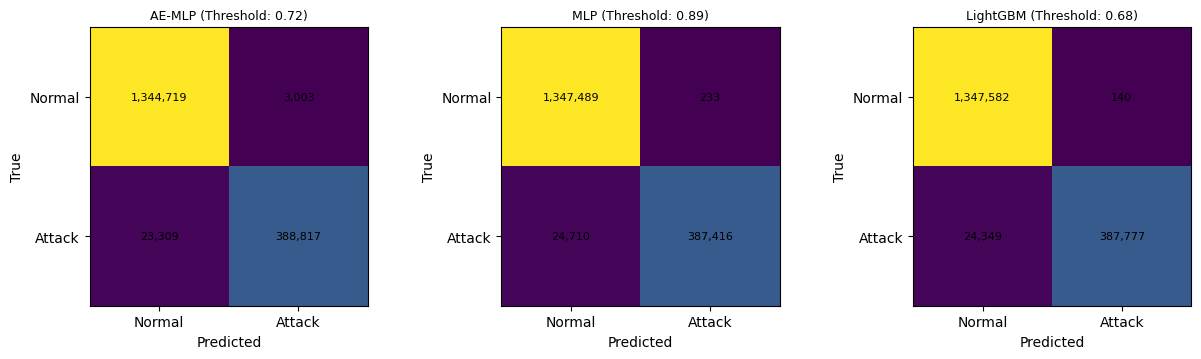

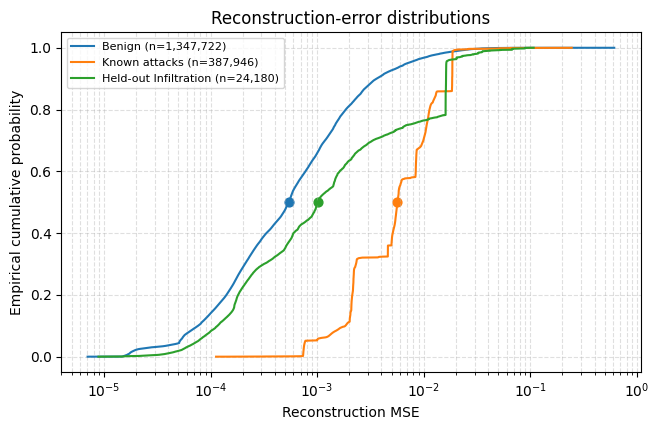

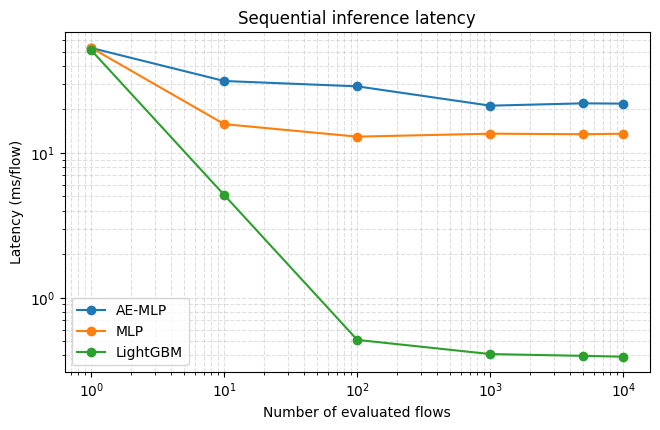

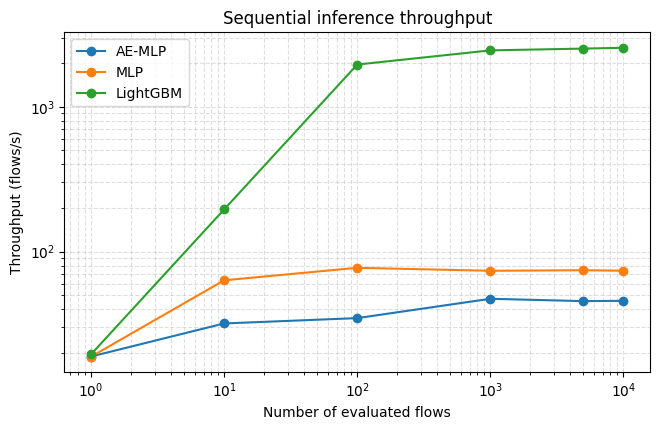

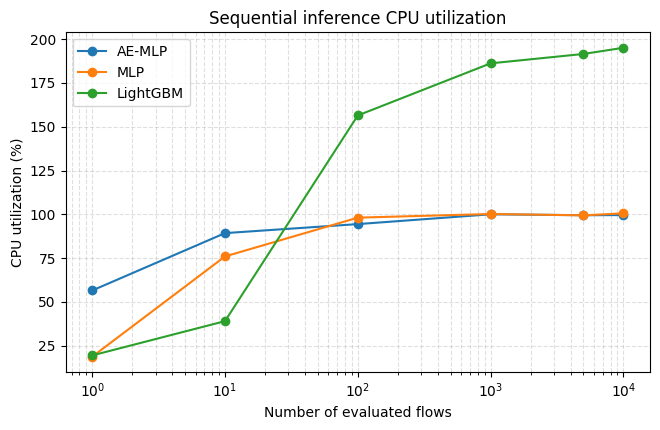

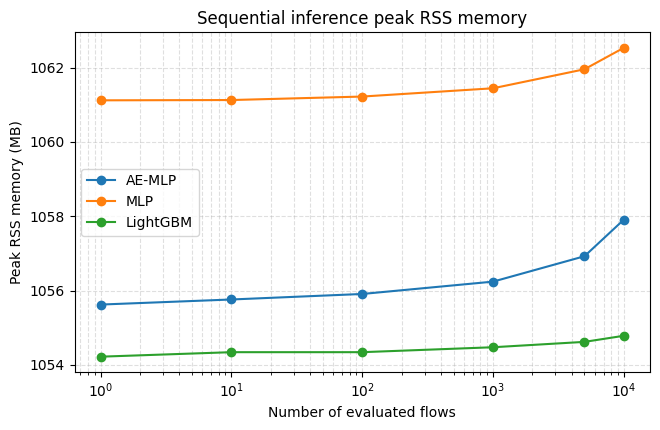

Saved figures to: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/figures


In [14]:
# ============================================================
# CELL 12 — FIGURES: CONFUSION MATRICES, RECON ECDF, BENCHMARK
# ============================================================

# 12A — Comparative confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
for ax, model in zip(axes, MODEL_ORDER):
    scores = scores_cse[model]
    pred = (scores > THRESHOLDS[model]).astype(int)
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"{model} (Threshold: {THRESHOLDS[model]:.2f})", fontsize=9)
    ax.set_xticks([0, 1], labels=["Normal", "Attack"])
    ax.set_yticks([0, 1], labels=["Normal", "Attack"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=8)
fig.tight_layout()
fig_path_pdf = FIG_DIR / "fig_comparative_confusion_matrices_final.pdf"
fig_path_png = FIG_DIR / "fig_comparative_confusion_matrices_final.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

# 12B — Reconstruction ECDF
recon_path = PRED_DIR / "ae_reconstruction_mse_cse_test.npz"
recon_err = np.load(recon_path)["reconstruction_mse"].astype(float)

benign_mask = y_test == 0
infil_mask = labels_test == ZERO_DAY_LABEL
known_attack_mask = (y_test == 1) & (~infil_mask)

def ecdf(vals):
    vals = np.sort(np.asarray(vals, dtype=float))
    y = np.arange(1, len(vals) + 1) / len(vals)
    return vals, y

plt.figure(figsize=(6.7, 4.4))
for name, mask in [
    ("Benign", benign_mask),
    ("Known attacks", known_attack_mask),
    ("Held-out Infiltration", infil_mask),
]:
    x, y = ecdf(recon_err[mask])
    plt.plot(x, y, label=f"{name} (n={mask.sum():,})")
    med = np.median(recon_err[mask])
    plt.scatter([med], [0.5], marker="o", s=40)

plt.xscale("log")
plt.xlabel("Reconstruction MSE")
plt.ylabel("Empirical cumulative probability")
plt.title("Reconstruction-error distributions")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=8)
plt.tight_layout()
ecdf_pdf = FIG_DIR / "fig_reconstruction_error_ecdf_final.pdf"
ecdf_png = FIG_DIR / "fig_reconstruction_error_ecdf_final.png"
plt.savefig(ecdf_pdf, bbox_inches="tight")
plt.savefig(ecdf_png, dpi=300, bbox_inches="tight")
plt.show()

# 12C — Sequential benchmark figures
df_plot = df_bench.copy()
df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=MODEL_ORDER, ordered=True)

def plot_benchmark_metric(y_col, ylabel, title, filename, logy=True):
    plt.figure(figsize=(6.7, 4.4))
    for model, g in df_plot.groupby("Model", observed=True):
        plt.plot(g["Flows"], g[y_col], marker="o", label=str(model))
    plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.xlabel("Number of evaluated flows")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    pdf = FIG_DIR / f"{filename}.pdf"
    png = FIG_DIR / f"{filename}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.show()

plot_benchmark_metric("Latency_ms_per_flow", "Latency (ms/flow)", "Sequential inference latency", "fig_sequential_latency_by_volume_final", logy=True)
plot_benchmark_metric("Throughput_flows_per_s", "Throughput (flows/s)", "Sequential inference throughput", "fig_sequential_throughput_by_volume_final", logy=True)
plot_benchmark_metric("Approx_Process_CPU_Util_%", "CPU utilization (%)", "Sequential inference CPU utilization", "fig_sequential_cpu_by_volume_final", logy=False)
plot_benchmark_metric("Monitor_RSS_MB_Max", "Peak RSS memory (MB)", "Sequential inference peak RSS memory", "fig_sequential_peakrss_by_volume_final", logy=False)

print("Saved figures to:", FIG_DIR)


In [15]:
# ============================================================
# CELL 13 — PAPER-READY LATEX TABLES
# ============================================================

def save_latex(df, filename, caption, label):
    tex = df.to_latex(index=False, escape=False, float_format="%.4f", caption=caption, label=label)
    path = TABLE_DIR / filename
    path.write_text(tex, encoding="utf-8")
    print("Saved:", path)
    return tex

# Table I
table_I = df_cse_percent[["Model", "F1 (%)", "FPR (%)", "Recall (%)", "PR-AUC", "ROC-AUC"]].copy()
for c in ["F1 (%)", "FPR (%)", "Recall (%)"]:
    table_I[c] = table_I[c].round(2)
for c in ["PR-AUC", "ROC-AUC"]:
    table_I[c] = table_I[c].round(4)
table_I.to_csv(TABLE_DIR / "paper_table_I_cse_test_metrics.csv", index=False)
save_latex(table_I, "paper_table_I_cse_test_metrics.tex", "Performance on the complete CSE-CIC-IDS2018 test set.", "tab:main")

# Table II
table_II = df_perclass_cse[["Attack Type", "n", "AE-MLP", "MLP", "LightGBM"]].copy()
for c in ["AE-MLP", "MLP", "LightGBM"]:
    table_II[c] = table_II[c].round(2)
table_II.to_csv(TABLE_DIR / "paper_table_II_cse_per_class_detection.csv", index=False)
save_latex(table_II, "paper_table_II_cse_per_class_detection.tex", "Per-class detection rates on CSE-CIC-IDS2018.", "tab:perclass")

# Table III
table_III = df_cross_percent[["Model", "FPR (%)", "Precision (%)", "Recall (%)", "F1 (%)", "PR-AUC", "ROC-AUC"]].copy()
for c in ["FPR (%)", "Precision (%)", "Recall (%)", "F1 (%)"]:
    table_III[c] = table_III[c].round(2)
for c in ["PR-AUC", "ROC-AUC"]:
    table_III[c] = table_III[c].round(4)
table_III.to_csv(TABLE_DIR / "paper_table_III_cicids2017_crossdataset.csv", index=False)
save_latex(table_III, "paper_table_III_cicids2017_crossdataset.tex", "Performance on the complete CICIDS2017 cross-dataset evaluation.", "tab:crossfull")

# Table IV
table_IV = df_unseen[["Attack Type", "n", "AE-MLP", "MLP", "LightGBM"]].copy()
for c in ["AE-MLP", "MLP", "LightGBM"]:
    table_IV[c] = table_IV[c].round(2)
table_IV.to_csv(TABLE_DIR / "paper_table_IV_cicids2017_unseen_detection.csv", index=False)
save_latex(table_IV, "paper_table_IV_cicids2017_unseen_detection.tex", "Detection rate on the CICIDS2017 unseen-attack subset.", "tab:crossunseen")

# Table V
paper_bench.to_csv(TABLE_DIR / "paper_table_V_sequential_cpu_memory.csv", index=False)
save_latex(paper_bench, "paper_table_V_sequential_cpu_memory.tex", "Sequential single-flow inference performance on pre-extracted CSE-CIC-IDS2018 test features.", "tab:computational")

print("\\nPaper-ready tables:")
print("TABLE I")
display(table_I)
print("TABLE II")
display(table_II)
print("TABLE III")
display(table_III)
print("TABLE IV")
display(table_IV)
print("TABLE V")
display(paper_bench)


Saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/paper_ready_tables/paper_table_I_cse_test_metrics.tex
Saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/paper_ready_tables/paper_table_II_cse_per_class_detection.tex
Saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/paper_ready_tables/paper_table_III_cicids2017_crossdataset.tex
Saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/paper_ready_tables/paper_table_IV_cicids2017_unseen_detection.tex
Saved: /content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant/paper_ready_tables/paper_table_V_sequential_cpu_memory.tex
\nPaper-ready tables:
TABLE I


,Model,F1 (%),FPR (%),Recall (%),PR-AUC,ROC-AUC
0,AE-MLP,96.73,0.22,94.34,0.9743,0.9788
1,MLP,96.88,0.02,94.00,0.9754,0.9815
2,LightGBM,96.94,0.01,94.09,0.9722,0.9784


TABLE II


,Attack Type,n,AE-MLP,MLP,LightGBM
0,Bot,42928,99.31,99.87,99.96
1,Brute Force -Web,92,21.74,38.04,58.70
2,Brute Force -XSS,35,20.00,57.14,80.00
3,DDOS attack-HOIC,102902,99.92,100.00,100.00
4,DDOS attack-LOIC-UDP,260,100.00,100.00,100.00
5,DDoS attacks-LOIC-HTTP,86428,99.84,99.93,99.98
6,DoS attacks-GoldenEye,6227,98.91,99.92,100.00
7,DoS attacks-Hulk,69287,99.98,100.00,100.00
8,DoS attacks-SlowHTTPTest,20983,100.00,100.00,100.00
9,DoS attacks-Slowloris,1648,76.52,78.46,91.87


TABLE III


,Model,FPR (%),Precision (%),Recall (%),F1 (%),PR-AUC,ROC-AUC
0,AE-MLP,13.09,40.77,36.77,38.66,0.3538,0.7173
1,MLP,5.20,45.10,17.43,25.15,0.3366,0.6307
2,LightGBM,0.92,85.92,22.79,36.02,0.6305,0.7945


TABLE IV


,Attack Type,n,AE-MLP,MLP,LightGBM
0,Heartbleed,11,0.00,81.82,0.0
1,Infiltration,36,5.56,0.00,0.0
2,PortScan,158804,73.93,0.05,0.0
3,All unseen attacks,158851,73.91,0.06,0.0


TABLE V


,Model,Latency (ms/flow),Throughput (flows/s),CPU (%),Peak RSS (MB),Size (MB)
5,AE-MLP,21.88,45.70,99.59,1057.91,0.15
11,MLP,13.56,73.74,100.57,1062.54,0.80
17,LightGBM,0.39,2552.71,195.03,1054.79,6.93


In [16]:
# ============================================================
# CELL 14 — REVIEWER CHECKLIST AND FINAL ZIP
# ============================================================

reviewer_checklist = {
    "R1_1_zero_filling": {
        "status": "addressed",
        "evidence": "cicids2017_feature_coverage_audit.csv; zero_filled_placeholders_used=False; all required 38 features present after name alignment.",
    },
    "R1_2_bootstrap_or_CI": {
        "status": "addressed",
        "evidence": "paper_ready_small_support_ci_summary.csv includes Wilson and bootstrap 95% confidence intervals.",
    },
    "R1_3_sequential_inference_across_volumes": {
        "status": "addressed",
        "evidence": "final_sequential_cpu_memory_benchmark_all_models.csv; volumes 1, 10, 100, 1000, 5000, 10000; each model in isolated subprocess.",
    },
    "R2_1_temper_zero_day_claim": {
        "status": "paper_text_required",
        "evidence": "Use selective/partial anomaly sensitivity wording in Abstract, Discussion, Conclusion.",
    },
    "R2_2_class_imbalance_support_discussion": {
        "status": "addressed",
        "evidence": "paper_table_II_cse_per_class_detection.csv and small-support CI summary.",
    },
    "R2_3_crossdataset_small_support_zero_fill": {
        "status": "addressed",
        "evidence": "paper_table_IV_cicids2017_unseen_detection.csv + CI + feature coverage audit.",
    },
    "R2_4_visualizations": {
        "status": "addressed",
        "evidence": "fig_comparative_confusion_matrices_final.pdf; fig_reconstruction_error_ecdf_final.pdf; PR-AUC/ROC-AUC in tables.",
    },
    "R2_5_latency_throughput_cpu_memory": {
        "status": "addressed",
        "evidence": "paper_table_V_sequential_cpu_memory.csv includes latency, throughput, CPU, Peak RSS, and Size.",
    },
}

final_summary = {
    "thresholds_final_validation_grid_0p01": THRESHOLDS,
    "model_order": MODEL_ORDER,
    "output_dir": str(OUT_DIR),
    "zero_filled_placeholders_used": False,
    "cse_test_flows": int(len(y_test)),
    "cicids2017_valid_flows": int(len(y_cross)),
    "sequential_volumes": SEQUENTIAL_VOLUMES,
    "reviewer_checklist": reviewer_checklist,
}

with open(OUT_DIR / "FINAL_reviewer_compliance_summary.json", "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

zip_path = OUT_DIR / "ICICoS2026_FINAL_all_in_one_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUT_DIR.rglob("*"):
        if p.is_file() and p != zip_path:
            zf.write(p, arcname=str(p.relative_to(OUT_DIR)))

print(json.dumps(final_summary, indent=2))
print("\\nZIP:", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Auto-download skipped:", e)


{
  "thresholds_final_validation_grid_0p01": {
    "AE-MLP": 0.72,
    "MLP": 0.89,
    "LightGBM": 0.68
  },
  "model_order": [
    "AE-MLP",
    "MLP",
    "LightGBM"
  ],
  "output_dir": "/content/drive/MyDrive/CICIDS2018/ICICoS2026_FINAL_all_in_one_reviewer_compliant",
  "zero_filled_placeholders_used": false,
  "cse_test_flows": 1759848,
  "cicids2017_valid_flows": 2827876,
  "sequential_volumes": [
    1,
    10,
    100,
    1000,
    5000,
    10000
  ],
  "reviewer_checklist": {
    "R1_1_zero_filling": {
      "status": "addressed",
      "evidence": "cicids2017_feature_coverage_audit.csv; zero_filled_placeholders_used=False; all required 38 features present after name alignment."
    },
    "R1_2_bootstrap_or_CI": {
      "status": "addressed",
      "evidence": "paper_ready_small_support_ci_summary.csv includes Wilson and bootstrap 95% confidence intervals."
    },
    "R1_3_sequential_inference_across_volumes": {
      "status": "addressed",
      "evidence": "final_sequen

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>